# 04. Pipeline прогноза и выявления аномалий

В четвертом ноутбуке собран воспроизводимый pipeline на основе предыдущих этапов: загрузка данных, построение признаков, обучение выбранной модели, прогноз на 24 часа вперед, поиск кандидатов в аномалии и сохранение результатов.

## Связь с заданием

Раздел закрывает финальный pipeline-пункт задания: подготовка данных, прогнозирование энергопотребления и выявление аномалий объединены в одном сценарии. В качестве финальной модели используется `RandomForest`, так как он показал лучшее качество на полном test-периоде среди ML-подходов.

In [13]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

## Конфигурация

В финальной конфигурации используется `QUICK_MODE=False`: модель обучается на всей train-истории, а anomaly-блок работает на расширенном историческом периоде. Горизонт прогноза зафиксирован равным 24 часам.

In [14]:
QUICK_MODE = False

forecast_horizon = 24
test_start = "2019-01-01"
target_col = "Consumption"
random_state = 42
anomaly_contamination = 0.01

if QUICK_MODE:
    train_history_days = 365
    n_estimators = 100
    anomaly_history_days = 365
else:
    train_history_days = None
    n_estimators = 400
    anomaly_history_days = 730

processed_path = Path("../data/processed/de_hourly_power_and_weather_prepared.csv")
raw_path = Path("../data/raw/de_hourly_power_and_weather.csv")
reports_dir = Path("../reports")
figures_dir = reports_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print("QUICK_MODE:", QUICK_MODE)
print("Горизонт прогноза, часов:", forecast_horizon)
print("Длина train-истории, дней:", train_history_days)
print("Число деревьев RandomForest:", n_estimators)
print("Длина истории для поиска аномалий, дней:", anomaly_history_days)

QUICK_MODE: False
Горизонт прогноза, часов: 24
Длина train-истории, дней: None
Число деревьев RandomForest: 400
Длина истории для поиска аномалий, дней: 730


## Загрузка и базовая проверка данных

In [15]:
if processed_path.exists():
    df = pd.read_csv(processed_path, parse_dates=["timestamp"])
    df = df.rename(columns={"timestamp": "ds"})
else:
    df = pd.read_csv(raw_path, parse_dates=["utc_timestamp"])
    df = df.rename(columns={"utc_timestamp": "ds"})

df["ds"] = pd.to_datetime(df["ds"], utc=True).dt.tz_convert(None)
df = df.sort_values("ds").reset_index(drop=True)

required_columns = {
    "ds",
    target_col,
    "Wind",
    "Solar",
    "Wind+Solar",
    "temperature",
    "radiation_direct_horizontal",
    "radiation_diffuse_horizontal",
}
missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError(f"Не хватает колонок: {missing_columns}")

freq_counts = df["ds"].diff().value_counts().head()
print("Период:", df["ds"].min(), "->", df["ds"].max())
print("Размер:", df.shape)
print("Дубликаты времени:", df["ds"].duplicated().sum())
print("Основные интервалы между наблюдениями:")
print(freq_counts)

df.head()

Период: 2015-01-01 00:00:00 -> 2019-12-31 23:00:00
Размер: (43824, 8)
Дубликаты времени: 0
Основные интервалы между наблюдениями:
ds
0 days 01:00:00    43823
Name: count, dtype: int64


,ds,Consumption,Wind,Solar,Wind+Solar,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal
0,2015-01-01 00:00:00,41.151,8.852,NaN,NaN,-0.981,0.0,0.0
1,2015-01-01 01:00:00,40.135,9.054,NaN,NaN,-1.035,0.0,0.0
2,2015-01-01 02:00:00,39.106,9.070,NaN,NaN,-1.109,0.0,0.0
3,2015-01-01 03:00:00,38.765,9.163,NaN,NaN,-1.166,0.0,0.0
4,2015-01-01 04:00:00,38.941,9.231,NaN,NaN,-1.226,0.0,0.0


## Функции признаков и метрик

Функция строит supervised dataset: признаки берутся на момент `ds`, а целевая переменная `y` соответствует энергопотреблению через 24 часа (`target_ds`). Так исключается утечка будущего.

In [16]:
weather_features = [
    "temperature",
    "radiation_direct_horizontal",
    "radiation_diffuse_horizontal",
]
energy_features = ["Wind", "Solar", "Wind+Solar"]
optional_features = weather_features + energy_features


def make_supervised_features(data, horizon=24):
    features = data.copy()
    features[optional_features] = features[optional_features].ffill().bfill()

    features["hour"] = features["ds"].dt.hour
    features["day_of_week"] = features["ds"].dt.dayofweek
    features["month"] = features["ds"].dt.month
    features["is_weekend"] = (features["day_of_week"] >= 5).astype(int)

    features["hour_sin"] = np.sin(2 * np.pi * features["hour"] / 24)
    features["hour_cos"] = np.cos(2 * np.pi * features["hour"] / 24)
    features["month_sin"] = np.sin(2 * np.pi * features["month"] / 12)
    features["month_cos"] = np.cos(2 * np.pi * features["month"] / 12)

    for lag in [1, 2, 3, 24, 48, 168]:
        features[f"lag_{lag}"] = features[target_col].shift(lag)

    features["rolling_mean_24"] = features[target_col].shift(1).rolling(24).mean()
    features["rolling_std_24"] = features[target_col].shift(1).rolling(24).std()
    features["rolling_mean_168"] = features[target_col].shift(1).rolling(168).mean()

    features["y"] = features[target_col].shift(-horizon)
    features["target_ds"] = features["ds"] + pd.Timedelta(hours=horizon)
    features = features.dropna().reset_index(drop=True)

    feature_cols = [
        "hour_sin", "hour_cos", "month_sin", "month_cos", "day_of_week", "is_weekend",
        "lag_1", "lag_2", "lag_3", "lag_24", "lag_48", "lag_168",
        "rolling_mean_24", "rolling_std_24", "rolling_mean_168",
    ] + optional_features

    return features, feature_cols


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    errors = np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator)
    return np.mean(errors) * 100


def score_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred),
    }

## Подготовка train/test

In [17]:
feature_df, feature_cols = make_supervised_features(df, horizon=forecast_horizon)

train_full = feature_df.loc[feature_df["ds"] < test_start].copy()
test = feature_df.loc[feature_df["ds"] >= test_start].copy()

if train_history_days is None:
    train = train_full.copy()
else:
    train_start = pd.Timestamp(test_start) - pd.Timedelta(days=train_history_days)
    train = train_full.loc[train_full["ds"] >= train_start].copy()

X_train = train[feature_cols]
y_train = train["y"]
X_test = test[feature_cols]
y_test = test["y"]

print("Train full:", train_full["ds"].min(), "->", train_full["ds"].max(), train_full.shape)
print("Train work:", train["ds"].min(), "->", train["ds"].max(), train.shape)
print("Test:", test["ds"].min(), "->", test["ds"].max(), test.shape)
print("Признаков:", len(feature_cols))

feature_df[["ds", "target_ds", target_col, "y"] + feature_cols].head()

Train full: 2015-01-08 00:00:00 -> 2018-12-31 23:00:00 (34896, 27)
Train work: 2015-01-08 00:00:00 -> 2018-12-31 23:00:00 (34896, 27)
Test: 2019-01-01 00:00:00 -> 2019-12-30 23:00:00 (8736, 27)
Признаков: 21


,ds,target_ds,Consumption,y,hour_sin,hour_cos,month_sin,month_cos,day_of_week,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,Wind,Solar,Wind+Solar
0,2015-01-08 00:00:00,2015-01-09 00:00:00,48.041,46.472,0.000000,1.000000,0.5,0.866025,3,0,50.460,54.070,58.348,45.125,45.011,41.151,60.113000,9.076208,51.398732,0.178,0.0,0.0,15.807,0.0,15.807
1,2015-01-08 01:00:00,2015-01-09 01:00:00,47.074,45.546,0.258819,0.965926,0.5,0.866025,3,0,48.041,50.460,54.070,44.217,44.015,40.135,60.234500,8.884335,51.439744,0.456,0.0,0.0,16.449,0.0,16.449
2,2015-01-08 02:00:00,2015-01-09 02:00:00,47.228,45.568,0.500000,0.866025,0.5,0.866025,3,0,47.074,48.041,50.460,44.368,44.049,39.106,60.353542,8.677108,51.481048,0.723,0.0,0.0,16.695,0.0,16.695
3,2015-01-08 03:00:00,2015-01-09 03:00:00,48.253,46.950,0.707107,0.707107,0.5,0.866025,3,0,47.228,47.074,48.041,45.298,44.730,38.765,60.472708,8.465074,51.529393,0.947,0.0,0.0,16.787,0.0,16.787
4,2015-01-08 04:00:00,2015-01-09 04:00:00,51.155,50.426,0.866025,0.500000,0.5,0.866025,3,0,48.253,47.228,47.074,48.598,46.416,38.941,60.595833,8.253610,51.585869,1.178,0.0,0.0,16.751,0.0,16.751


## Финальная модель прогноза

В качестве финальной модели используется `RandomForestRegressor`. Модель обучается внутри единого pipeline и сразу формирует таблицу прогнозов, ошибок и итоговых метрик качества.

In [18]:
forecast_model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=12 if QUICK_MODE else None,
    random_state=random_state,
    n_jobs=-1,
)

forecast_model.fit(X_train, y_train)
y_pred = forecast_model.predict(X_test)

forecast_scores = score_predictions(y_test, y_pred)
forecast_scores_df = pd.DataFrame([{"model": "RandomForest", **forecast_scores}])
forecast_scores_df

,model,MAE,RMSE,SMAPE
0,RandomForest,1.430971,2.305991,2.612157


In [19]:
forecast_result = test[["ds", "target_ds", target_col, "y"]].copy()
forecast_result = forecast_result.rename(columns={target_col: "consumption_at_feature_time", "y": "actual"})
forecast_result["prediction"] = y_pred
forecast_result["residual"] = forecast_result["actual"] - forecast_result["prediction"]
forecast_result["abs_error"] = forecast_result["residual"].abs()

forecast_result.head()

,ds,target_ds,consumption_at_feature_time,actual,prediction,residual,abs_error
34896,2019-01-01 00:00:00,2019-01-02 00:00:00,41.562,42.813,45.443938,-2.630938,2.630938
34897,2019-01-01 01:00:00,2019-01-02 01:00:00,40.100,42.318,44.576840,-2.258840,2.258840
34898,2019-01-01 02:00:00,2019-01-02 02:00:00,38.883,41.934,45.152715,-3.218715,3.218715
34899,2019-01-01 03:00:00,2019-01-02 03:00:00,38.806,43.607,43.523748,0.083252,0.083252
34900,2019-01-01 04:00:00,2019-01-02 04:00:00,38.593,46.463,44.902078,1.560922,1.560922


WindowsPath('../reports/figures/04_random_forest_forecast.png')

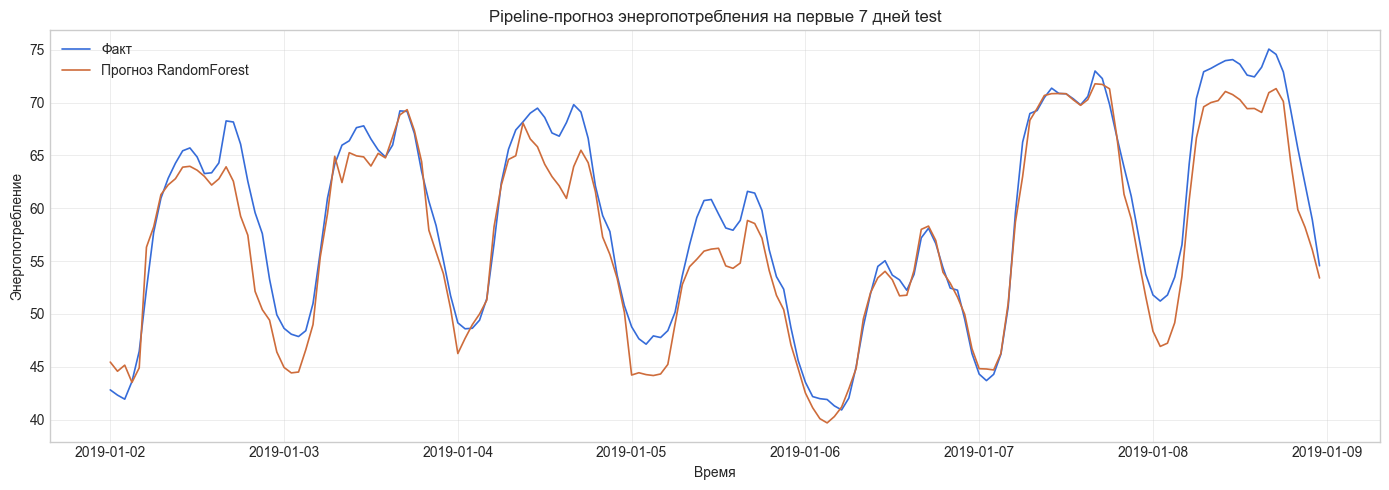

In [20]:
plot_n = 24 * 7
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(forecast_result["target_ds"].head(plot_n), forecast_result["actual"].head(plot_n), label="Факт", linewidth=1.2)
ax.plot(forecast_result["target_ds"].head(plot_n), forecast_result["prediction"].head(plot_n), label="Прогноз RandomForest", linewidth=1.2)
ax.set_title("Pipeline-прогноз энергопотребления на первые 7 дней test")
ax.set_xlabel("Время")
ax.set_ylabel("Энергопотребление")
ax.legend()
plt.tight_layout()

forecast_figure_path = figures_dir / "04_random_forest_forecast.png"
fig.savefig(forecast_figure_path, dpi=150, bbox_inches="tight")
forecast_figure_path

## Pipeline выявления аномалий

Использованы несколько независимых методов, а итоговый флаг формируется по большинству голосов. Такой подход снижает риск отметить точку как аномальную только из-за срабатывания одного чувствительного алгоритма.

In [21]:
def make_anomaly_dataset(data):
    anomaly_data = data[["ds", target_col] + weather_features].copy()
    if anomaly_history_days is not None:
        anomaly_start = pd.Timestamp(test_start) - pd.Timedelta(days=anomaly_history_days)
        anomaly_data = anomaly_data.loc[anomaly_data["ds"] >= anomaly_start].copy()

    anomaly_data[weather_features] = anomaly_data[weather_features].ffill().bfill()
    anomaly_data["hour"] = anomaly_data["ds"].dt.hour
    anomaly_data["day_of_week"] = anomaly_data["ds"].dt.dayofweek
    anomaly_data["rolling_mean_24"] = anomaly_data[target_col].rolling(24, min_periods=12).mean()
    anomaly_data["rolling_std_24"] = anomaly_data[target_col].rolling(24, min_periods=12).std()
    anomaly_data["z_score_24"] = (anomaly_data[target_col] - anomaly_data["rolling_mean_24"]) / anomaly_data["rolling_std_24"]
    anomaly_data = anomaly_data.dropna().reset_index(drop=True)

    anomaly_feature_cols = [
        target_col,
        "temperature",
        "radiation_direct_horizontal",
        "radiation_diffuse_horizontal",
        "hour",
        "day_of_week",
    ]
    return anomaly_data, anomaly_feature_cols


anomaly_df, anomaly_feature_cols = make_anomaly_dataset(df)
X_anomaly = anomaly_df[anomaly_feature_cols]

anomaly_df.head()

,ds,Consumption,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,hour,day_of_week,rolling_mean_24,rolling_std_24,z_score_24
0,2017-01-01 11:00:00,44.371,0.352,129.0645,99.0808,11,6,41.429000,2.924673,1.005925
1,2017-01-01 12:00:00,40.634,0.993,109.5724,93.4026,12,6,41.367846,2.808829,-0.261264
2,2017-01-01 13:00:00,40.869,0.953,63.5433,77.4788,13,6,41.332214,2.701926,-0.171439
3,2017-01-01 14:00:00,41.919,-0.008,16.1864,41.0011,14,6,41.371333,2.608046,0.209991
4,2017-01-01 15:00:00,44.072,-1.294,0.4359,2.7208,15,6,41.540125,2.608504,0.970623


In [22]:
anomaly_df["anomaly_zscore"] = anomaly_df["z_score_24"].abs() > 3

isolation_forest = IsolationForest(contamination=anomaly_contamination, random_state=random_state, n_jobs=-1)
anomaly_df["anomaly_isolation_forest"] = isolation_forest.fit_predict(X_anomaly) == -1

lof = LocalOutlierFactor(n_neighbors=35, contamination=anomaly_contamination)
anomaly_df["anomaly_lof"] = lof.fit_predict(X_anomaly) == -1

one_class_svm = make_pipeline(StandardScaler(), OneClassSVM(nu=anomaly_contamination, gamma="scale"))
anomaly_df["anomaly_one_class_svm"] = one_class_svm.fit_predict(X_anomaly) == -1

anomaly_cols = [
    "anomaly_zscore",
    "anomaly_isolation_forest",
    "anomaly_lof",
    "anomaly_one_class_svm",
]
anomaly_df["anomaly_votes"] = anomaly_df[anomaly_cols].sum(axis=1)
anomaly_df["is_anomaly"] = anomaly_df["anomaly_votes"] >= 2

anomaly_summary = anomaly_df[anomaly_cols + ["is_anomaly"]].sum().sort_values(ascending=False)
anomaly_summary

anomaly_one_class_svm       264
anomaly_isolation_forest    263
anomaly_lof                 263
is_anomaly                  101
anomaly_zscore               56
dtype: int64

WindowsPath('../reports/figures/04_anomaly_candidates.png')

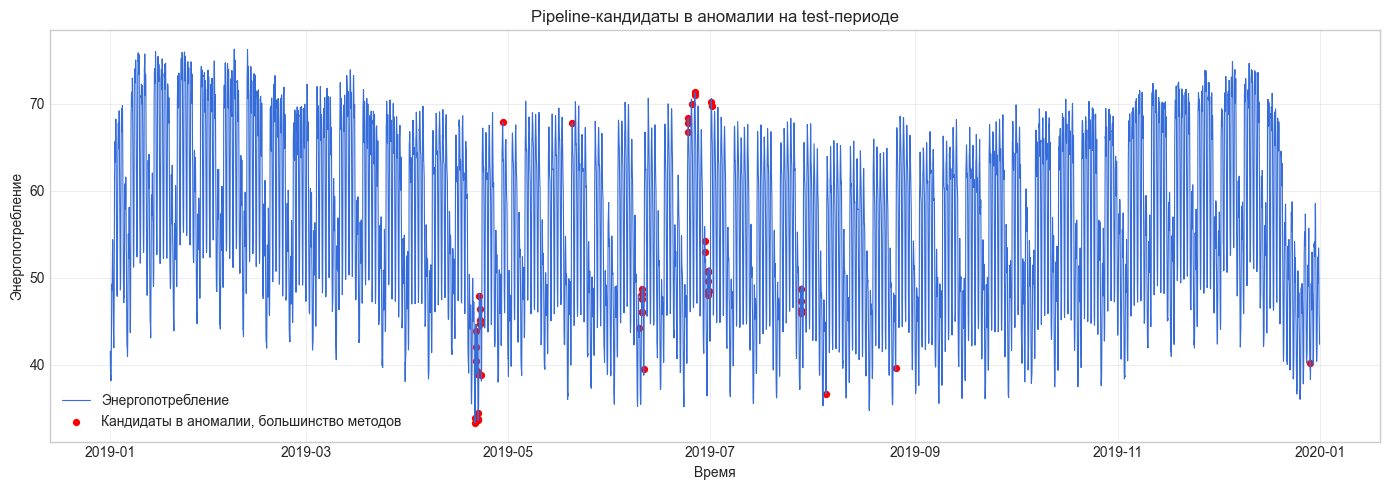

In [23]:
plot_anomalies = anomaly_df.loc[anomaly_df["ds"] >= test_start].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_anomalies["ds"], plot_anomalies[target_col], label="Энергопотребление", linewidth=0.8)
ax.scatter(
    plot_anomalies.loc[plot_anomalies["is_anomaly"], "ds"],
    plot_anomalies.loc[plot_anomalies["is_anomaly"], target_col],
    color="red",
    s=18,
    label="Кандидаты в аномалии, большинство методов",
)
ax.set_title("Pipeline-кандидаты в аномалии на test-периоде")
ax.set_xlabel("Время")
ax.set_ylabel("Энергопотребление")
ax.legend()
plt.tight_layout()

anomaly_figure_path = figures_dir / "04_anomaly_candidates.png"
fig.savefig(anomaly_figure_path, dpi=150, bbox_inches="tight")
anomaly_figure_path

## Сохранение результатов

In [24]:
forecast_path = reports_dir / "04_forecast_predictions.csv"
anomaly_path = reports_dir / "04_anomaly_candidates.csv"
summary_path = reports_dir / "04_pipeline_summary.json"
model_path = reports_dir / "04_random_forest_pipeline.joblib"

forecast_result.to_csv(forecast_path, index=False)
anomaly_df.loc[anomaly_df["is_anomaly"]].to_csv(anomaly_path, index=False)

joblib.dump(
    {
        "model": forecast_model,
        "feature_cols": feature_cols,
        "forecast_horizon": forecast_horizon,
        "target_col": target_col,
        "created_from": "04_anomalies_pipeline.ipynb",
    },
    model_path,
)

pipeline_summary = {
    "quick_mode": QUICK_MODE,
    "forecast_horizon_hours": forecast_horizon,
    "final_model": "RandomForest",
    "forecast_scores": forecast_scores,
    "n_train_rows": int(len(train)),
    "n_test_rows": int(len(test)),
    "anomaly_contamination": anomaly_contamination,
    "anomaly_counts": {key: int(value) for key, value in anomaly_summary.to_dict().items()},
    "forecast_path": str(forecast_path),
    "anomaly_path": str(anomaly_path),
    "summary_path": str(summary_path),
    "model_path": str(model_path),
    "forecast_figure_path": str(forecast_figure_path),
    "anomaly_figure_path": str(anomaly_figure_path),
}

summary_path.write_text(json.dumps(pipeline_summary, ensure_ascii=False, indent=2), encoding="utf-8")

pipeline_config_df = pd.DataFrame([
    {"Показатель": "QUICK_MODE", "Значение": QUICK_MODE},
    {"Показатель": "Горизонт прогноза, часов", "Значение": forecast_horizon},
    {"Показатель": "Финальная модель", "Значение": "RandomForest"},
    {"Показатель": "Train rows", "Значение": len(train)},
    {"Показатель": "Test rows", "Значение": len(test)},
    {"Показатель": "Contamination для anomaly detection", "Значение": anomaly_contamination},
])

anomaly_counts_df = (
    anomaly_summary
    .rename("count")
    .reset_index()
    .rename(columns={"index": "method"})
)

artifact_paths_df = pd.DataFrame([
    {"Артефакт": "Прогнозы", "Путь": str(forecast_path)},
    {"Артефакт": "Кандидаты в аномалии", "Путь": str(anomaly_path)},
    {"Артефакт": "JSON-сводка", "Путь": str(summary_path)},
    {"Артефакт": "Модель", "Путь": str(model_path)},
    {"Артефакт": "График прогноза", "Путь": str(forecast_figure_path)},
    {"Артефакт": "График аномалий", "Путь": str(anomaly_figure_path)},
])

print("Конфигурация pipeline")
display(pipeline_config_df)
print("Метрики финальной модели")
display(forecast_scores_df)
print("Количество кандидатов в аномалии по методам")
display(anomaly_counts_df)
print("Сохраненные артефакты")
display(artifact_paths_df)

Конфигурация pipeline


,Показатель,Значение
0,QUICK_MODE,False
1,"Горизонт прогноза, часов",24
2,Финальная модель,RandomForest
3,Train rows,34896
4,Test rows,8736
5,Contamination для anomaly detection,0.01


Метрики финальной модели


,model,MAE,RMSE,SMAPE
0,RandomForest,1.430971,2.305991,2.612157


Количество кандидатов в аномалии по методам


,method,count
0,anomaly_one_class_svm,264
1,anomaly_isolation_forest,263
2,anomaly_lof,263
3,is_anomaly,101
4,anomaly_zscore,56


Сохраненные артефакты


,Артефакт,Путь
0,Прогнозы,..\reports\04_forecast_predictions.csv
1,Кандидаты в аномалии,..\reports\04_anomaly_candidates.csv
2,JSON-сводка,..\reports\04_pipeline_summary.json
3,Модель,..\reports\04_random_forest_pipeline.joblib
4,График прогноза,..\reports\figures\04_random_forest_forecast.png
5,График аномалий,..\reports\figures\04_anomaly_candidates.png


## Интерпретация результатов

Финальный pipeline объединяет результаты предыдущих этапов в воспроизводимый сценарий: подготовка признаков, обучение `RandomForest`, прогнозирование энергопотребления, поиск кандидатов в аномалии и сохранение артефактов.

`RandomForest` выбран как финальная модель, потому что на полном test-периоде он показал лучшее качество среди ML-моделей. По сохраненному pipeline-запуску `RandomForest` получил `SMAPE` около 2.61%, `MAE` около 1.43 и `RMSE` около 2.31. Это подтверждает, что лаговые, календарные, rolling- и погодные признаки дают устойчивое качество прогноза.

Аномалии интерпретируются как кандидаты для проверки, а не как подтвержденные сбои. Итоговый флаг `is_anomaly` ставится только тогда, когда точку поддержали минимум два метода. Такой подход делает результат менее чувствительным к единичным ложным срабатываниям.

Ноутбук сохраняет прогнозы, кандидатов в аномалии, графики, json-сводку и обученную модель в каталоге `reports/`. Эти артефакты используются как результат финального pipeline.